Q1

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart_dataset.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
# Again, check unique levels and see any marker is used or left out for a missing level
for col in df.columns:
    if df[col].dtype == object:
        print (col, df[col].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


In [6]:
def encode_onehot(_df, _f):
    _df2 = pd.get_dummies(_df[_f], prefix=_f, prefix_sep=' - ', dtype=int)
    _df3 = pd.concat([_df, _df2], axis=1)
    _df3 = _df3.drop([_f], axis=1)
    return _df3

In [7]:
df_o = encode_onehot(df, 'Sex')

In [8]:
df_o = encode_onehot(df_o, 'ChestPainType')
df_o = encode_onehot(df_o, 'RestingECG')
df_o = encode_onehot(df_o, 'ExerciseAngina')
df_o = encode_onehot(df_o, 'ST_Slope')

In [9]:
df_o.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex - F,Sex - M,ChestPainType - ASY,...,ChestPainType - NAP,ChestPainType - TA,RestingECG - LVH,RestingECG - Normal,RestingECG - ST,ExerciseAngina - N,ExerciseAngina - Y,ST_Slope - Down,ST_Slope - Flat,ST_Slope - Up
0,40,140,289,0,172,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [10]:
df_o.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex - F,Sex - M,ChestPainType - ASY,...,ChestPainType - NAP,ChestPainType - TA,RestingECG - LVH,RestingECG - Normal,RestingECG - ST,ExerciseAngina - N,ExerciseAngina - Y,ST_Slope - Down,ST_Slope - Flat,ST_Slope - Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,...,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377,0.210240,0.789760,0.540305,...,0.221133,0.050109,0.204793,0.601307,0.193900,0.595861,0.404139,0.068627,0.501089,0.430283
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414,0.407701,0.407701,0.498645,...,0.415236,0.218289,0.403770,0.489896,0.395567,0.490992,0.490992,0.252957,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df_o[scale_features] = scaler.fit_transform(df_o[scale_features])


In [12]:
df_o.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex - F,Sex - M,ChestPainType - ASY,...,ChestPainType - NAP,ChestPainType - TA,RestingECG - LVH,RestingECG - Normal,RestingECG - ST,ExerciseAngina - N,ExerciseAngina - Y,ST_Slope - Down,ST_Slope - Flat,ST_Slope - Up
0,-1.433140,0.410909,0.825070,0,1.382928,-0.832432,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.491752,-0.171961,0,0.754157,0.105664,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.129513,0.770188,0,-1.525138,-0.832432,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.302825,0.139040,0,-1.132156,0.574711,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.951331,-0.034755,0,-0.581981,-0.832432,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [13]:
X = df_o.loc[:, df_o.columns != 'HeartDisease'].values
y = df_o.loc[:, df_o.columns == 'HeartDisease'].values.ravel()

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# 10-fold CV evaluation of a classifier
def eval_classifier(_clf, _X, _y):
    accuracies = []
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        _clf.fit(_X[train_index], _y[train_index])
        y_pred = _clf.predict(_X[test_index])
        accuracies += [accuracy_score(_y[test_index], y_pred)]
    return np.array(accuracies)

In [15]:

acc = eval_classifier(GaussianNB(),
                      X, y)
print(f'Naive Bayes CV accuracy={np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Naive Bayes CV accuracy=0.86 ±0.034


In [16]:

acc = eval_classifier(SVC(kernel='linear', probability=True),
                      X, y)
print(f'Linear SVC CV accuracy={np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Linear SVC CV accuracy=0.86 ±0.029


In [17]:

acc = eval_classifier(MLPClassifier(),
                      X, y)
print(f'Neural Network CV accuracy={np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Neural Network CV accuracy=0.87 ±0.034


In [18]:

acc = eval_classifier(DecisionTreeClassifier(),
                      X, y)
print(f'Decision Tree CV accuracy={np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Decision Tree CV accuracy=0.80 ±0.043


In [19]:

acc = eval_classifier(RandomForestClassifier(),
                      X, y)
print(f'Random Forest CV accuracy={np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Random Forest CV accuracy=0.86 ±0.025


Q2

In [20]:
ensemble_nb = []

for _ in range(100):
    clf = GaussianNB()
    ensemble_nb.append(clf)

In [21]:
ensemble_svc = []

for _ in range(100):
    clf = SVC(kernel="linear", C=0.05, probability=True, max_iter=600)
    ensemble_svc.append(clf)

In [22]:
ensemble_mlp = []

for _ in range(100):
    clf = MLPClassifier(hidden_layer_sizes=(3, 3), max_iter=30, tol=1e-1)
    ensemble_mlp.append(clf)

In [23]:
ensemble_dt = []

for _ in range(100):
    clf = DecisionTreeClassifier(max_depth=5, max_features=5)
    ensemble_dt.append(clf)

In [24]:
%%time

def eval_singleweak(_X, _y, _niters, clf):
    accuracies = []
    for _ in range(_niters):

        kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        for train_index, test_index in kf.split(_X, _y):
            clf.fit(_X[train_index], _y[train_index])
            y_pred = clf.predict(_X[test_index])
            accuracies += [accuracy_score(_y[test_index], y_pred)]
    return np.array(accuracies)

acc = eval_singleweak(X, y, 100, ensemble_nb[0])

# Sanity
print(f'total #results= {len(acc)}')

print(f'NB Weak learners average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

acc = eval_singleweak(X, y, 100, ensemble_svc[0])

# Sanity
print(f'total #results= {len(acc)}')

print(f'SVC Weak learners average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

acc = eval_singleweak(X, y, 100, ensemble_mlp[0])

# Sanity
print(f'total #results= {len(acc)}')

print(f'MLP Weak learners average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

acc = eval_singleweak(X, y, 100, ensemble_dt[0])

# Sanity
print(f'total #results= {len(acc)}')

print(f'DT Weak learners average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

total #results= 1000
NB Weak learners average Acc= 0.86 ±0.034
total #results= 1000
SVC Weak learners average Acc= 0.86 ±0.033
total #results= 1000
MLP Weak learners average Acc= 0.55 ±0.098
total #results= 1000
DT Weak learners average Acc= 0.83 ±0.040
CPU times: user 24.1 s, sys: 55.9 ms, total: 24.2 s
Wall time: 24.2 s


Q3

In [25]:
import random
def ensemble_fit(ensemble, X_train, y_train, subsample_ratio=0.2):
    n_samples = int(subsample_ratio * len(X_train))
    #print(n_samples)
    #print(n_samples)
    for classifier in ensemble:
        indices = random.sample(range(len(X_train)), n_samples)
        X_subset = X_train[indices]
        y_subset = y_train[indices]
        classifier.fit(X_subset, y_subset)
    return None

In [26]:
def ensemble_predict(ensemble, X):
    probas = np.array([clf.predict_proba(X) for clf in ensemble])
    avg_probas = np.mean(probas, axis=0)
    return np.argmax(avg_probas, axis=1)

Q4

Q5 and Q6

In [27]:
%%time

def eval_ensemble(_X, _y, _niter, ensemble, subsample_ratio = 0.2):
    accuracies = []
    for i in range(_niter):
        # 10-fold CV
        kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=i)
        for train_index, test_index in kf.split(_X, _y):
            e_clf = ensemble_fit(ensemble, _X[train_index], _y[train_index], subsample_ratio)
            y_pred = ensemble_predict(ensemble, _X[test_index])
            accuracies += [accuracy_score(_y[test_index], y_pred)]

    return np.array(accuracies)

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 2.62 μs


In [28]:
acc = eval_ensemble(X,y,10,ensemble_nb, subsample_ratio = 0.03)

In [29]:
print(f'Ensemble learners average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Ensemble learners average Acc= 0.85 ±0.034


In [30]:
acc = eval_ensemble(X,y,10,ensemble_svc, subsample_ratio = 0.2)

In [31]:
print(f'Ensemble learners average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')

Ensemble learners average Acc= 0.86 ±0.034


In [32]:
subsample_ratios = [0.03, 0.05, 0.1, 0.2]

In [33]:
ensemble_nb_accuracies = []
ensemble_svc_accuracies = []
ensemble_mlp_accuracies = []
ensemble_dt_accuracies = []
regular_nb_accuracies = []
regular_svc_accuracies = []
regular_mlp_accuracies = []
regular_dt_accuracies = []

In [34]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,ensemble_nb, subsample_ratio = s)
    print(f'Ensemble NB learners with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    ensemble_nb_accuracies.append(np.mean(acc))

Ensemble NB learners with subsample ratio = 0.03 average Acc= 0.85 ±0.035
Ensemble NB learners with subsample ratio = 0.05 average Acc= 0.85 ±0.035
Ensemble NB learners with subsample ratio = 0.1 average Acc= 0.85 ±0.037
Ensemble NB learners with subsample ratio = 0.2 average Acc= 0.86 ±0.035


In [35]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,[GaussianNB()], subsample_ratio = s)
    print(f'Regular NB with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    regular_nb_accuracies.append(np.mean(acc))

Regular NB with subsample ratio = 0.03 average Acc= 0.75 ±0.081
Regular NB with subsample ratio = 0.05 average Acc= 0.77 ±0.086
Regular NB with subsample ratio = 0.1 average Acc= 0.81 ±0.059
Regular NB with subsample ratio = 0.2 average Acc= 0.85 ±0.037


In [36]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,ensemble_svc, subsample_ratio = s)
    print(f'Ensemble SVC learners with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    ensemble_svc_accuracies.append(np.mean(acc))

Ensemble SVC learners with subsample ratio = 0.03 average Acc= 0.85 ±0.033
Ensemble SVC learners with subsample ratio = 0.05 average Acc= 0.85 ±0.034
Ensemble SVC learners with subsample ratio = 0.1 average Acc= 0.85 ±0.034
Ensemble SVC learners with subsample ratio = 0.2 average Acc= 0.86 ±0.035


In [37]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,[SVC(kernel="linear", C=0.05, probability=True, max_iter=600)], subsample_ratio = s)
    print(f'Regular SVC with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    regular_svc_accuracies.append(np.mean(acc))

Regular SVC with subsample ratio = 0.03 average Acc= 0.76 ±0.125
Regular SVC with subsample ratio = 0.05 average Acc= 0.83 ±0.039
Regular SVC with subsample ratio = 0.1 average Acc= 0.84 ±0.035
Regular SVC with subsample ratio = 0.2 average Acc= 0.85 ±0.035


In [38]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,ensemble_mlp, subsample_ratio = s)
    print(f'Ensemble MLP learners with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    ensemble_mlp_accuracies.append(np.mean(acc))

Ensemble MLP learners with subsample ratio = 0.03 average Acc= 0.56 ±0.102
Ensemble MLP learners with subsample ratio = 0.05 average Acc= 0.59 ±0.104
Ensemble MLP learners with subsample ratio = 0.1 average Acc= 0.57 ±0.096
Ensemble MLP learners with subsample ratio = 0.2 average Acc= 0.58 ±0.091


In [39]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,[MLPClassifier(hidden_layer_sizes=(3, 3), max_iter=30, tol=1e-1)], subsample_ratio = s)
    print(f'Regular MLP with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    regular_mlp_accuracies.append(np.mean(acc))

Regular MLP with subsample ratio = 0.03 average Acc= 0.52 ±0.077
Regular MLP with subsample ratio = 0.05 average Acc= 0.51 ±0.062
Regular MLP with subsample ratio = 0.1 average Acc= 0.51 ±0.064
Regular MLP with subsample ratio = 0.2 average Acc= 0.49 ±0.068


In [40]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,ensemble_dt, subsample_ratio = s)
    print(f'Ensemble DT learners with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    ensemble_dt_accuracies.append(np.mean(acc))

Ensemble DT learners with subsample ratio = 0.03 average Acc= 0.86 ±0.037
Ensemble DT learners with subsample ratio = 0.05 average Acc= 0.86 ±0.032
Ensemble DT learners with subsample ratio = 0.1 average Acc= 0.87 ±0.034
Ensemble DT learners with subsample ratio = 0.2 average Acc= 0.87 ±0.032


In [41]:
for s in subsample_ratios:
    acc = eval_ensemble(X,y,10,[DecisionTreeClassifier(max_depth=5, max_features=5)], subsample_ratio = s)
    print(f'Regular DT with subsample ratio = {s} average Acc= {np.mean(acc):.2f} {chr(177)}{np.std(acc):.3f}')
    regular_dt_accuracies.append(np.mean(acc))

Regular DT with subsample ratio = 0.03 average Acc= 0.74 ±0.076
Regular DT with subsample ratio = 0.05 average Acc= 0.75 ±0.062
Regular DT with subsample ratio = 0.1 average Acc= 0.77 ±0.051
Regular DT with subsample ratio = 0.2 average Acc= 0.79 ±0.042


Q7

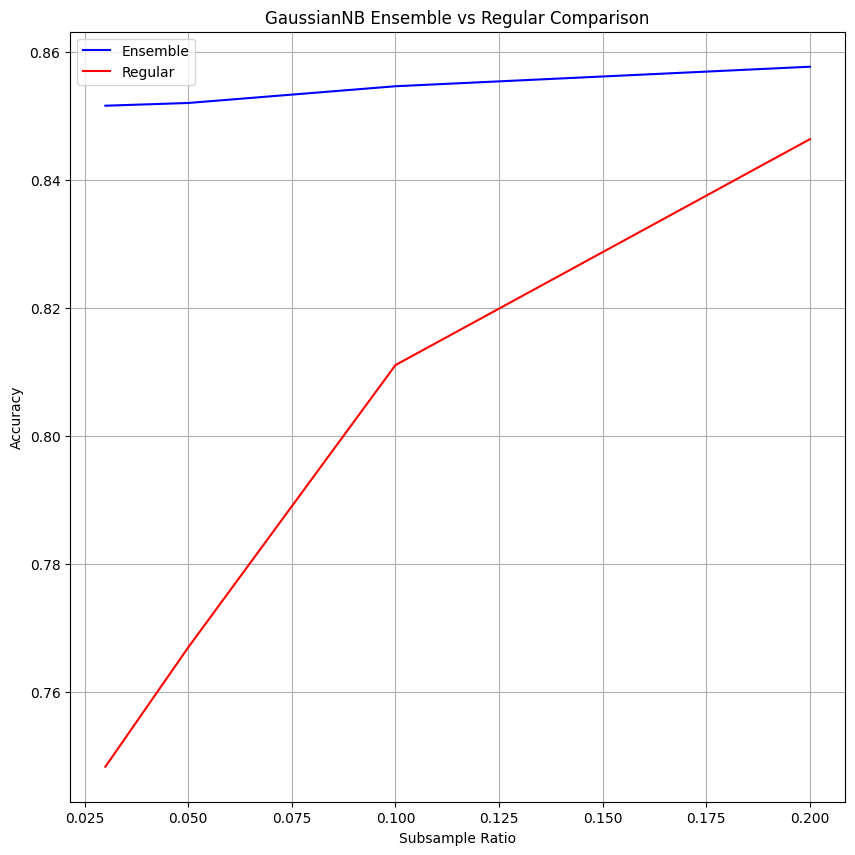

In [42]:
plt.figure(figsize=(10, 10))
plt.plot(subsample_ratios, ensemble_nb_accuracies, label='Ensemble', color='blue')
plt.plot(subsample_ratios, regular_nb_accuracies, label='Regular', color='red')
plt.xlabel('Subsample Ratio')
plt.ylabel('Accuracy')
plt.title('GaussianNB Ensemble vs Regular Comparison')
plt.legend()
plt.grid(True)
plt.show()

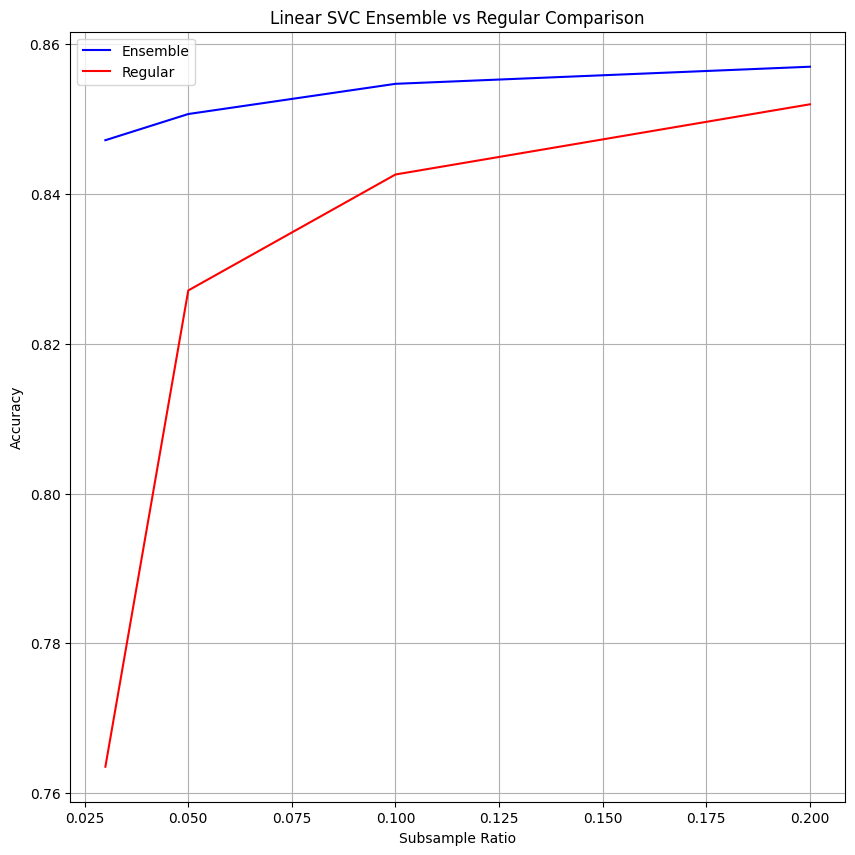

In [43]:
plt.figure(figsize=(10, 10))
plt.plot(subsample_ratios, ensemble_svc_accuracies, label='Ensemble', color='blue')
plt.plot(subsample_ratios, regular_svc_accuracies, label='Regular', color='red')
plt.xlabel('Subsample Ratio')
plt.ylabel('Accuracy')
plt.title('Linear SVC Ensemble vs Regular Comparison')
plt.legend()
plt.grid(True)
plt.show()

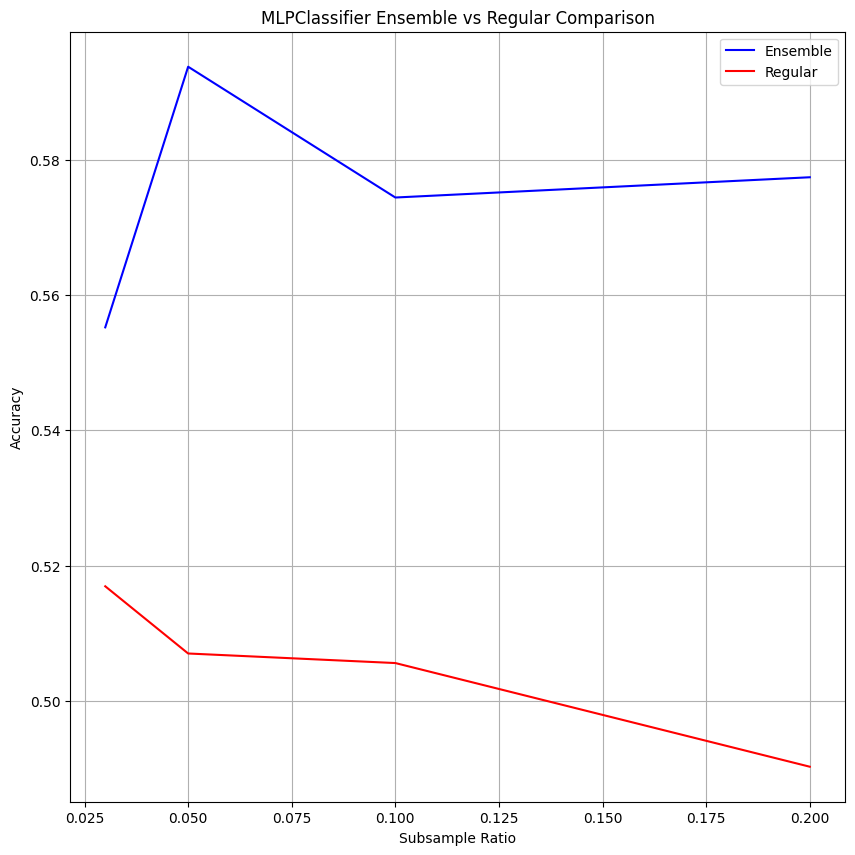

In [44]:
plt.figure(figsize=(10, 10))
plt.plot(subsample_ratios, ensemble_mlp_accuracies, label='Ensemble', color='blue')
plt.plot(subsample_ratios, regular_mlp_accuracies, label='Regular', color='red')
plt.xlabel('Subsample Ratio')
plt.ylabel('Accuracy')
plt.title('MLPClassifier Ensemble vs Regular Comparison')
plt.legend()
plt.grid(True)
plt.show()

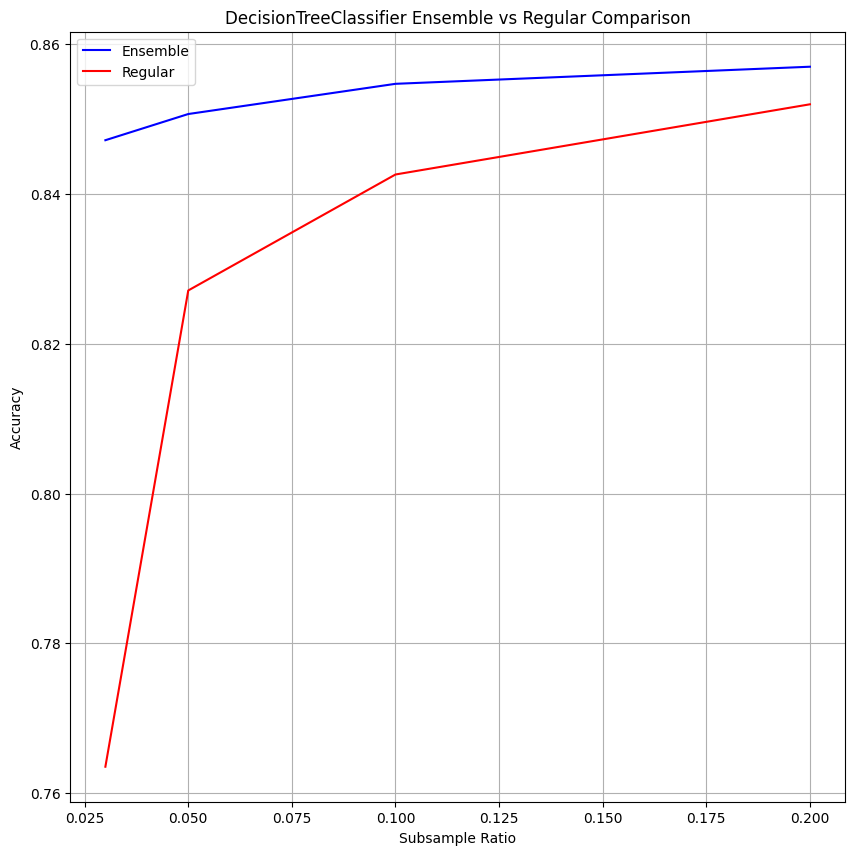

In [45]:
plt.figure(figsize=(10, 10))
plt.plot(subsample_ratios, ensemble_svc_accuracies, label='Ensemble', color='blue')
plt.plot(subsample_ratios, regular_svc_accuracies, label='Regular', color='red')
plt.xlabel('Subsample Ratio')
plt.ylabel('Accuracy')
plt.title('DecisionTreeClassifier Ensemble vs Regular Comparison')
plt.legend()
plt.grid(True)
plt.show()

The ensemble classifier with a bunch of weak learners generally seem to perform better than the regular version of those classifiers. As subsample ratio increases, the regular classifier performance gets much better except for the MLP which stays consistent. As for the ensemble classifiers, when the subsample ratio increases, the decision tree and linear svc gets better gradually. For the MLP and GuassianNB it stays reletivaly consistent for the ensemble classifier. This shows the power of ensemble learners. We also saw from doing the experiments that ensemble learners reduce our standard deviation which makes it more consistent.